In [2]:
!pip3.10 install sktime

/bin/bash: line 1: pip3.10: command not found


# Гипотеза 
Выдвинем следующую гипотезу: 

Различные преобразования по-разному влияют на качество прогнозирования для разных типов рядов. 

В ходе проверки гипотезы будут использованы следующие преобразований: 
- Log1p преобразования;
- Box-Cox;
- Differencing.

Целью исследования является выяснение эффектов, производимых указанными преобразованиями на различные временные ряды, и сравнение качества предсказаний. 

## План работы: 
1. EDA
2. Построение бейзлайнов (Naive и Seasonal Naive)
3. Кластеризация рядов методом TimeSeriesKMeans
4. Фиксирование глобальной модели (CatBoost)
5. Применение различных трансформаций и сравнение полученных эффектов
6. Анализ по кластерам 


# Первичная работа с данными

## Загрузка данных

В качестве датасета выбран М4 monthly. 



In [22]:
import pandas as pd
import numpy as np
from src.data_loader import load_data
from src.data_loader import select_n_series
from src.data_loader import split_data
import matplotlib.pyplot as plt

In [4]:
df = load_data()

In [5]:
df.head() 

series_value
series_name timestamp                        
T1          1976-06-01 12:00:00        8000.0
            1976-07-01 12:00:00        8350.0
            1976-08-01 12:00:00        8570.0
            1976-09-01 12:00:00        7700.0
            1976-10-01 12:00:00        7080.0

Выделим 200 рядов. 

In [6]:
df = select_n_series(df, 200)

In [7]:
df["series_name"].nunique()

200

In [8]:
df.head()

,series_name,timestamp,series_value
0,T1,1976-06-01 12:00:00,8000.0
1,T1,1976-07-01 12:00:00,8350.0
2,T1,1976-08-01 12:00:00,8570.0
3,T1,1976-09-01 12:00:00,7700.0
4,T1,1976-10-01 12:00:00,7080.0


In [9]:
df.shape

(80149, 3)

Посмотрим базовые статистики

In [18]:
print(df['series_value'].describe())

count    80149.000000
mean      4115.913641
std       4192.748204
min        115.590000
25%       1252.560000
50%       2438.410000
75%       5650.000000
max      55260.000000
Name: series_value, dtype: float64


Статистика по длине рядов

In [19]:
series_lengths = df.groupby('series_name').size()
print(f"\nДлина рядов:")
print(f"Минимальная: {series_lengths.min()}")
print(f"Максимальная: {series_lengths.max()}")
print(f"Средняя: {series_lengths.mean():.0f}")
print(f"Медианная: {series_lengths.median():.0f}")


Длина рядов:
Минимальная: 82
Максимальная: 1248
Средняя: 401
Медианная: 379


Проверка на пропуски в данных

In [35]:
print(f"Пропуски в данных: {df['series_value'].isnull().sum()}")
df.isna().sum()

Пропуски в данных: 0


series_name     0
timestamp       0
series_value    0
dtype: int64

Проверка на дубли в данных

In [36]:
print(f"Дубли в данных: {int(df.duplicated().sum())}")

Дубли в данных: 0


Перед разбиением посмотрим длины рядов. 

In [20]:
pd.set_option('display.max_rows', None)

In [11]:
df.groupby("series_name").size()

series_name
T1       487
T10      384
T100     310
T101     262
T102     262
T103     185
T104     157
T105     439
T106      91
T107     187
T108     187
T109      85
T11      636
T110      85
T111      85
T112      85
T113     187
T114     840
T115     439
T116     439
T117     840
T118     840
T119     840
T12      936
T120     840
T121     840
T122    1248
T123     840
T124     301
T125     840
T126     301
T127     301
T128     301
T129     301
T13      936
T130     306
T131      86
T132      86
T133      86
T134      86
T135      86
T136      86
T137      86
T138     504
T139     504
T14      744
T140     504
T141     175
T142     349
T143     175
T144     391
T145    1092
T146     504
T147      94
T148     840
T149     840
T15      744
T150     840
T151     840
T152     600
T153      86
T154      86
T155      86
T156     600
T157     516
T158     840
T159     516
T16      744
T160      91
T161      97
T162      97
T163     247
T164     247
T165     127
T166     837
T167      82


Видим, что длины у рядов различаются - в диапазоне от 82 точек до 1248. Тем не менее, это все еще позволяет разбить ряды на train и test таким образом, чтобы в test попало фиксированное число точек. 

Посмотрим на распределение значений

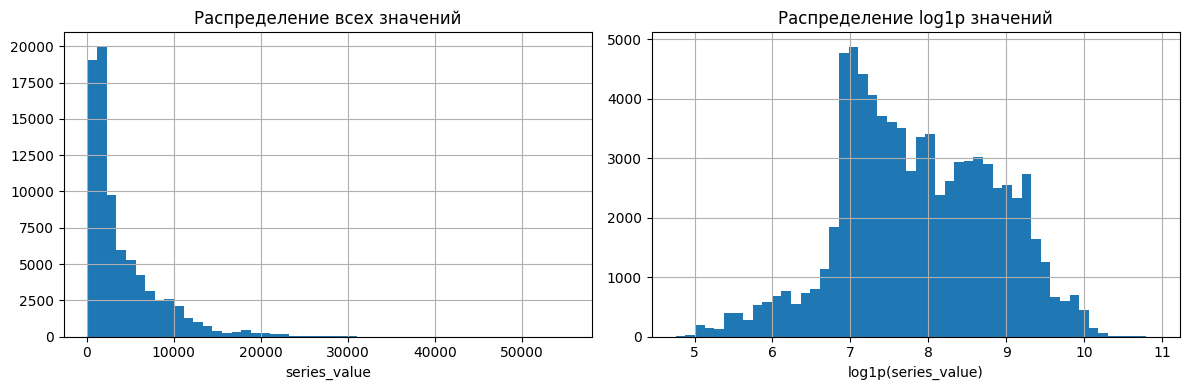

In [23]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['series_value'].hist(bins=50)
plt.title('Распределение всех значений')
plt.xlabel('series_value')

plt.subplot(1, 2, 2)

np.log1p(df['series_value']).hist(bins=50)
plt.title('Распределение log1p значений')
plt.xlabel('log1p(series_value)')

plt.tight_layout()
plt.show()

**Выводы:** 
1) Распределение целевой переменной  
- Сильная правосторонняя асимметрия: среднее (4116) сильно больше медианы (2438)
- Большой разброс: от 115 до 55,260 (размах в 480 раз)
- Лог-трансформация явно будет полезна (гистограмма log1p выглядит более нормальной)

2) Разная длина рядов (может повлиять на кластеризацию)  
- Минимум: 82 точки
- Максимум: 1248 точек
- Медиана: 379 точек

## Train-test разбиение

Применим разбиение с фиксированным временным горизонтом. Для начала проанализируем, возможно ли произвести разбиение на train и test следующим образом: из 487 строк каждого ряда добавим 20 в test, а остальное оставим в train.

Проверим, действительно ли длина всех рядов позволит взять 20 точек в тест

In [27]:
# проверка на самом коротком ряду
series_lengths = df.groupby('series_name').size()
min_length = series_lengths.min()
print(f"\nСамый короткий ряд имеет {min_length} точки")
print(f"При горизонте 20, в тест уйдет {20/min_length:.1%} данных")
print(f"Train останется: {min_length - 20} точек")


Самый короткий ряд имеет 82 точки
При горизонте 20, в тест уйдет 24.4% данных
Train останется: 62 точек


In [28]:
# оценка пропорции train/test для различных рядов
test_fractions = []
for series_name in df['series_name'].unique():
    series_data = df[df['series_name'] == series_name]
    total_points = len(series_data)
    test_fraction = 20 / total_points
    test_fractions.append(test_fraction)

print(f"\nАнализ доли тестовой выборки (горизонт в 20 точек):")
print(f"Минимальная доля теста: {min(test_fractions):.1%} (у самого длинного ряда)")
print(f"Максимальная доля теста: {max(test_fractions):.1%} (у самого короткого ряда)") 
print(f"Средняя доля теста: {np.mean(test_fractions):.1%}")
print(f"Медианная доля теста: {np.median(test_fractions):.1%}")


Анализ доли тестовой выборки (горизонт в 20 точек):
Минимальная доля теста: 1.6% (у самого длинного ряда)
Максимальная доля теста: 24.4% (у самого короткого ряда)
Средняя доля теста: 8.4%
Медианная доля теста: 5.3%


**Выводы:** При разбиении временных рядов на обучающую и тестовую выборки мы можем использовать фиксированный горизонт прогнозирования: для каждого ряда последние 20 точек берем в тест, а все предыдущие остаются в обучении. Даже для самого короткого ряда с 82 точками в обучении остаётся 62 точки, чего, на наш взгляд, достаточно для построения модели. В результате получили 76 149 наблюдений в train и 4 000 в test, при этом доля теста варьируется от 1.6% до 24.4% в зависимости от длины ряда.



In [29]:
df_train, df_test = split_data(df, horizon=20)

In [30]:
df_train.shape

(76149, 3)

In [31]:
df_test.shape

(4000, 3)

## EDA
### Построим графики

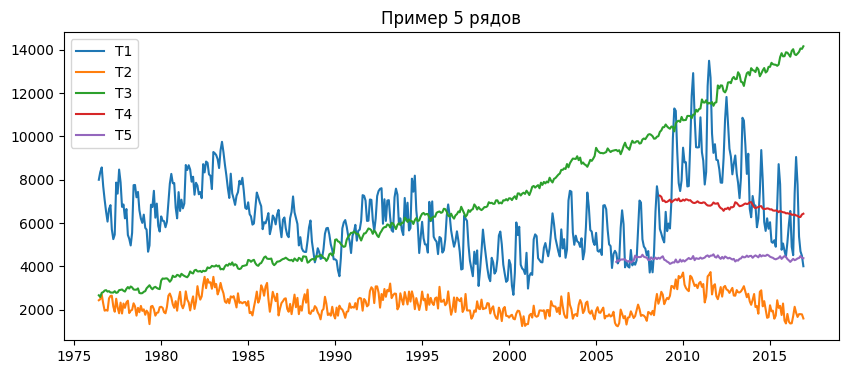

In [15]:
sample = df["series_name"].unique()[:5]
fig, axes = plt.subplots(figsize=(10, 4))
for s in sample: 
    subset = df[df["series_name"] == s]
    plt.plot(subset["timestamp"], subset["series_value"], label=s)

plt.title('Пример 5 рядов')
plt.legend()
plt.show()

На графике видно, что ряды сильно отличаются не только по длине, но и по компонентам ряда: для многих из представленных рядов можно выделить тренд, сезонность, а также можно отметить разницу в дисперсии. 

Таким образом, первичный визуальный анализ позволяет сделать следующие выводы для первыз пяти рядов (Т1-Т5):
- Т1: Видим длинные циклы длиной приблизительно в 10 лет, а также более мелкие циклы приблизительно в 1 год. Выделяется мультипликативная сезонность.
- Т2: На первый взгляд, не выделяется тренд или сезонность. Ряд выглядит так, словно колеблется вокруг некоторого среднего значения, ожнако стоит произвести дополнительное исследование относительно циклов. Дисперсия постоянна во времени. 
- Т3: Отчетливый восходящий тренд. Дисперсия меньше. 
- Т4: Виден плавный нисходящий тренд. Дисперсия аддитивная, небольшая.
- Т5: Нельзя выделить тренд или циклы. Дисперсия аддитивная, небольшая. 

# Бейзлайны

Далее рассмотрим два простейших бейзлайна: Naive и Seasonal Naive. 

Выбор бейзлайнов обусловлен простотой, а также разнообразием рядов датасета. Таким образом, Naive будет представлять простейший примитивный бейзлайн, универсальный для всех рядов, а Seasonal Naive будет показателен для исследования сравнения рядов с выраженной сезонностью. 

Напомним общую информацию по рассматриваемым бейзлайнам. 

### Naive model 
Следующее значение будет равняться предыдущему значнию ряда. Другими словами: 
$$ \hat{y}_{t+h} = y_t $$


### Seasonal Naive model 
Следующее значение будет равняться аналогичному значению предыдущего цикла. Другими словами: 

$ \hat{y}_{t+h} = y_{t+h-s}$, где $s$ - длина сезона/цикла. Учтем, что в рассматриваемом датасете $s=12$. 

## Метрики
В качестве метрик будем использовать MAE и SMAPE. 

Выбор каждой из метрик имеет объяснение: в то время, как MAE показывает абсолютную ошибку, метрика SMAPE показывает относительную ошибку, что позволяет корректно оценивать ряды из рассматриваемого датасета. Вспомним, что ряды в датасете очень различны, и SMAPE поможет выстроить корректную схему оценивания качества преобразований рядов.  



In [17]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive
from src.metrics import smape
from sklearn.metrics import mean_absolute_error

In [18]:
df_train_copy = df_train.copy()

df_train_copy = df_train_copy.rename(columns={
    "series_name": "unique_id",
    "timestamp": "ds",
    "series_value": "y"
})

In [19]:
df_test_copy = df_test.copy()

df_test_copy = df_test_copy.rename(columns={
    "series_name": "unique_id",
    "timestamp": "ds",
    "series_value": "y"
})

In [20]:
sf = StatsForecast(
    models = [
        Naive(),
        SeasonalNaive(season_length=12)
    ],
    freq='MS',
    verbose=True
)
sf.fit(df_train_copy)
preds = sf.predict(h=20)

In [21]:
preds.head()

,unique_id,ds,Naive,SeasonalNaive
0,T1,2015-05-01 12:00:00,5210.0,6220.0
1,T1,2015-06-01 12:00:00,5210.0,7450.0
2,T1,2015-07-01 12:00:00,5210.0,9370.0
3,T1,2015-08-01 12:00:00,5210.0,7980.0
4,T1,2015-09-01 12:00:00,5210.0,6050.0


In [22]:
results = preds.merge(df_test_copy, on=["unique_id", "ds"])

In [23]:
# посчитаем метрики
mae_naive = mean_absolute_error(results["y"], results["Naive"])
smape_naive = smape(results["y"], results["Naive"])

mae_seasonal = mean_absolute_error(results["y"], results["SeasonalNaive"])
smape_seasonal = smape(results["y"], results["SeasonalNaive"])

In [24]:
baseline_results = pd.DataFrame({
    "model": ["Naive", "SeasonalNaive"],
    "MAE": [mae_naive, mae_seasonal],
    "SMAPE": [smape_naive, smape_seasonal]
})

baseline_results

,model,MAE,SMAPE
0,Naive,470.863303,10.607311
1,SeasonalNaive,582.677488,12.353751


**Вывод:** Видим, что Naive является более сильным бейзлайном: результаты значений метрик MAE и SMAPE лучше (MAE=470 против MAE=582 для Seasonal и SMAPE=10.6 против SMAPE=12.4 у Seasonal). 

Исходя из полученных данным, можем заключить, что сильная сезонность не характерна для большинства рядов, либо структура сезонности нестабильна. Рассмотрим этот вопрос позднее. 

# Кластеризация

В данном блоке рассматривается кластеризация рядов методом TimeSeriesKMeans с целью анализа трансформаций рядов, разделенных на кластеры. 

Мы знаем, что ряды в датасете различаются по длине, по наличию тренда/сезонности, по уровню стабилизации дисперсии. 

Для определения числа кластеров выбран коэффициент silhouette, поскольку он отображает и схожесть элементов внутри одного кластера, и непохожесть различных кластеров между собой. 

In [ ]:
from sklearn.metrics import silhouette_score